## WQD 7001 Principle of Data Science
## Topic: Obesity Risk Prediction Using Machine Learning Model
### Group 6


### Group Members:

| Name | Matrix Number |
| :---: | :---: |
| CEN LINZE | 25089511 |
| HAOCHEN SHEN | 25074646 |
| ONG CHEN YAN | 25093281 |
| SHAO JINBO | 25086040 |
| GUO JIAQIAN | 25085503 |

### Data Collection

* This dataset is collected from Kaggle. The title of the dataset is Obesity Prediction Dataset. This dataset consists of 2,111 samples and 17 initial features (expanded to 18 with the calculated BMI).

* Each of feature is showed below:
    * **Demographics**: Gender, Age.
    * **Physical Measurements**: Height, Weight.
    * **Dietary Habits**: Frequent consumption of high-caloric food (FAVC), frequency of consumption of vegetables (FCVC), number of main meals (NCP), consumption of food between meals (CAEC), daily water consumption (CH2O), and alcohol consumption (CALC).
    * **Lifestyle & Physical Activity**: Family history of overweight, Smoking habit (SMOKE), calories consumption monitoring (SCC), physical activity frequency (FAF), time spent using technology devices (TUE), and primary mode of transportation (MTRANS).
    * **Target Variable**: NObeyesdad, which categorizes individuals into 7 specific obesity levels (ranging from Insufficient Weight to Obesity Type III).

**Import Libraries**

In [89]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.api.types import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("obesity_questionnaire_dataset.csv")
MODEL_PATH = Path("personal_obesity_bundle.joblib")
REPORT_PATH = Path("personal_model_report.json")
RANDOM_STATE = 42

TARGET_CLASS = "NObeyesdad"
RISK_CLASSES = {"Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"}
AT_RISK_CLASSES = {
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
}

**Upload and read the dataset**

In [90]:
# Load dataset
data = pd.read_csv(DATA_PATH)
print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


**List down the row and columns in the dataset**

In [91]:
data.shape

(2111, 17)

**Get the information of the column and number of non missing values as well as data type and the statistical data overview**

In [92]:
print("Columns:")
print(data.columns.tolist())
print("\nData types and non-null counts:")
data.info()

display(data.describe(include="all").T)

Columns:
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SM

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2111,2,Male,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2111.0,NaN,NaN,NaN,24.3126,6.345968,14.0,19.947192,22.77789,26.0,61.0
Height,2111.0,NaN,NaN,NaN,1.701677,0.093305,1.45,1.63,1.700499,1.768464,1.98
Weight,2111.0,NaN,NaN,NaN,86.586058,26.191172,39.0,65.473343,83.0,107.430682,173.0
family_history_with_overweight,2111,2,yes,1726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2111,2,yes,1866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2111.0,NaN,NaN,NaN,2.419043,0.533927,1.0,2.0,2.385502,3.0,3.0
NCP,2111.0,NaN,NaN,NaN,2.685628,0.778039,1.0,2.658738,3.0,3.0,4.0
CAEC,2111,4,Sometimes,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2111,2,no,2067,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Cleaning

* **Missing Values and Imputation**: A comprehensive missing value check was executed using `data.isnull().sum()`. The result showed zero missing values across all rows and columns. Consequently, no imputation techniques (such as mean, median, or KNN imputation) were required or applied.
* **Duplicate Records Handling**: A check using `data.duplicated().sum()` successfully identified 24 duplicated rows. As standard protocol dictates, handling these duplicates is required before model training to prevent data leakage and overfitting to specific sample patterns.
* **Feature Engineering**: To enhance predictive power, a new feature, BMI (Body Mass Index) was derived (Weight / (Height ** 2)). This provides a scientifically recognized, standardized indicator of obesity, reducing the model's reliance on raw, unscaled height and weight values.

**Missing Values and Imputation**

In [93]:
missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percent": (data.isna().mean() * 100).round(2),
})
print("Total missing values:", int(data.isna().sum().sum()))
display(missing_summary)

Total missing values: 0


,missing_count,missing_percent
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history_with_overweight,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


**Duplicated Record Handling**

In [94]:
duplicate_rows = int(data.duplicated().sum())
print("Duplicated rows:", duplicate_rows)
if duplicate_rows > 0:
    display(data[data.duplicated()].head())
else:
    print("No duplicated rows found.")

# Remove the duplicated record
if duplicate_rows > 0:
    data = data.drop_duplicates()
    print("Duplicated rows after data cleaning:", int(data.duplicated().sum()))

Duplicated rows: 24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I


Duplicated rows after data cleaning: 0


**Create new feature BMI for data visualization in EDA**

In [95]:
data["BMI"] = data["Weight"] / (data["Height"] ** 2)
data["Obesity_Risk"] = data[TARGET_CLASS].isin(RISK_CLASSES)
data["At_Risk"] = data[TARGET_CLASS].isin(AT_RISK_CLASSES)

print("Obesity prevalence (%):", round(data["Obesity_Risk"].mean() * 100, 2))
print("Overweight or obesity prevalence (%):", round(data["At_Risk"].mean() * 100, 2))

Obesity prevalence (%): 46.57
Overweight or obesity prevalence (%): 73.69


### Exploratory Data Analysis (EDA)

#### **Explore the distribution of dataset for BMI, Age, Gender and Obesity Level**

This step is to explore whether there is bias in the data distribution.
* **Age**: A wide age ranges from 14 years old to 61 years old is covered in this dataset. A wide age range is important for the prediction because people from different ages may have different dietary habits, metabolic rates, and physical activity patterns.
* **BMI**: This dataset consists of people from different BMI values with wide range from underweight (13) to obesity (51). BMI is an important indicator of obesity and is calculated as weight divided by height squared. It provides useful information about individuals’ body mass status as well as an important feature for obesity level prediction.
* **Obesity Level**: This dataset consists of people from different obesity level. The distribution of each obesity level are approximately the same with no significant bias to any of the obesity level.
* **Gender**: There is no significant bias for gender in this dataset. The total number of male and female are approximately the same. It is crucial to ensure that there is no significant bias in the gender distribution because males and females may differ in body composition, lifestyle habits, and obesity-related risk.
* **Transportation**: There is a significant bias in the transportation where most of the respondent are using public transport. After study, transportation is not considered as a key feature for obesity risk prediction as it highly depends on an individual travel distance to the public transport as well as the advancement of the city infrastructure. 

Text(0, 0.5, 'Frequency')

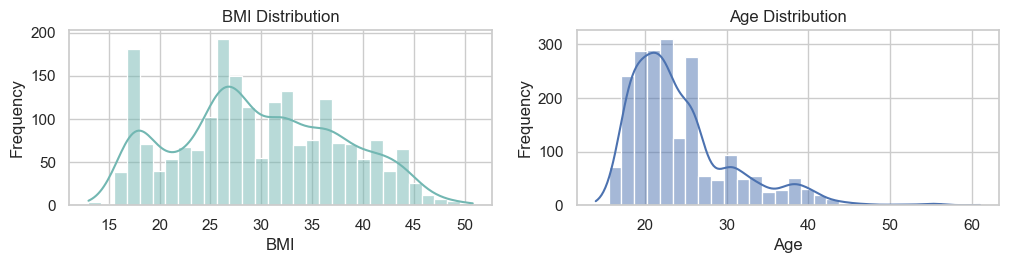

In [96]:
# Distribution of BMI
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
sns.histplot(data["BMI"], bins=30, kde=True, color="#72B7B2")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

# Distribution of Age
plt.subplot(2, 2, 2)
sns.histplot(data["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

Text(0, 0.5, 'Number of Records')

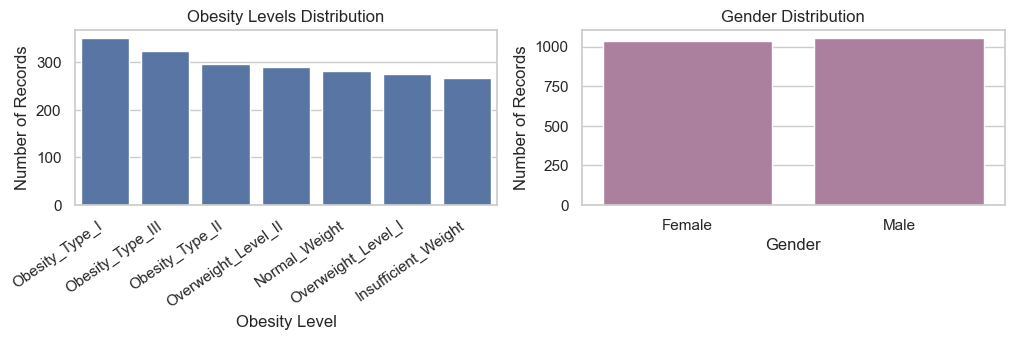

In [97]:
# Distribution of Obesity Level
plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
sns.countplot(
    data=data,
    x="NObeyesdad",
    order=data["NObeyesdad"].value_counts().index
)
plt.title("Obesity Levels Distribution")
plt.xlabel("Obesity Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")

# Distribution of Gender
plt.subplot(2, 2, 2)
sns.countplot(data=data, x="Gender", color="#B279A2")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Records")

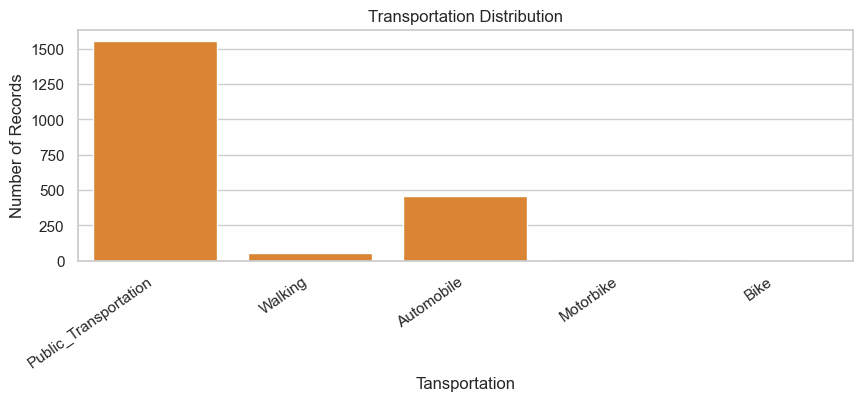

In [98]:
# Distribution of Transportation
plt.figure(figsize=(10, 3))
sns.countplot(
    data=data,
    x="MTRANS",
    color="#F58518"
)
plt.title("Transportation Distribution")
plt.xlabel("Tansportation")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")
plt.show()

#### **Explore the relationship between Obesity Level with Gender, Height and Weight, Dietary Habit, Transportation and Physical Activity**

This step is to identify what are the key features that will affect an individual obesity level.
* **Gender**: Although obesity type III are mainly coming from female and obesity type II are mainly coming from male, however there is no significant concentration of obesity level to certain gender, hence there is not enough evidence to prove that gender can affect obesity level.
* **Dietary**: High-caloric food intake is usually associated with weight gain and obesity risk. Based on the graph, it showed that individuals who frequently consume high-caloric food are more concentrated in higher obesity levels. Hence, this is an important feature for obesity risk prediction.
* **Family History**: Family history may reflect both genetic factors and shared household lifestyle habits. Based on the graph, it showed that individuals with family history are more common in higher obesity levels, hence this feature is an important feature for obesity risk prediction.
* **Transportation**: Transportation method can indirectly reflect daily physical activity. However, based on graph, most of the individuals with public transport has obesity issues which is unlikely happened. One the main reasons is because majority of the respondents are using public transport in this dataset. Besides, there is still a possibility that even though walking to the bus or train station helps to reduce calories, but the long periods spent sitting during a commute combined with subsequent sedentary desk jobs limit overall energy expenditure. This feature is not a good feature as it might influence by the distance of an individual travel to the public transport too.
* **Weight and Height**: Based on the scatter plot, it can be concluded that individuals with higher weight are more likely to belong to higher obesity categories.
* **Physical Activity**: Physical activity is closely related to weight control. Lower physical activity frequency may be associated with higher obesity levels. Based on the box plot, individual with obesity has lower frequency of physical activity, hence this variable would be an important lifestyle feature for prediction.

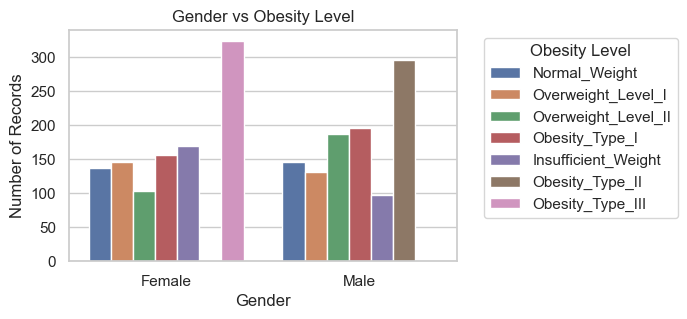

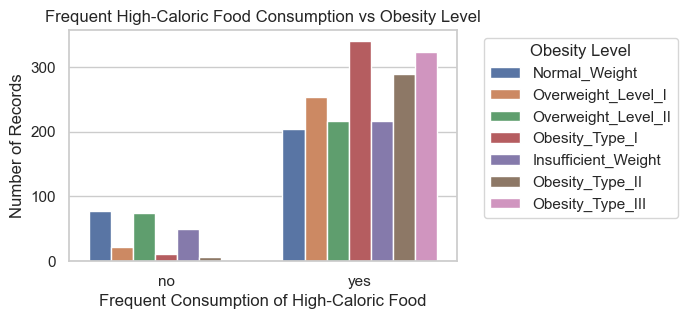

In [99]:
# Explore the relationship between gender and obesity level
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x="Gender", hue="NObeyesdad")
plt.title("Gender vs Obesity Level")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Explore the relationship between dietary and obesity level
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x="FAVC", hue="NObeyesdad")
plt.title("Frequent High-Caloric Food Consumption vs Obesity Level")
plt.xlabel("Frequent Consumption of High-Caloric Food")
plt.ylabel("Number of Records")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

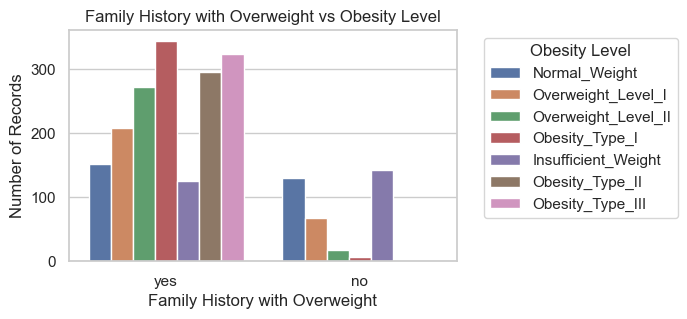

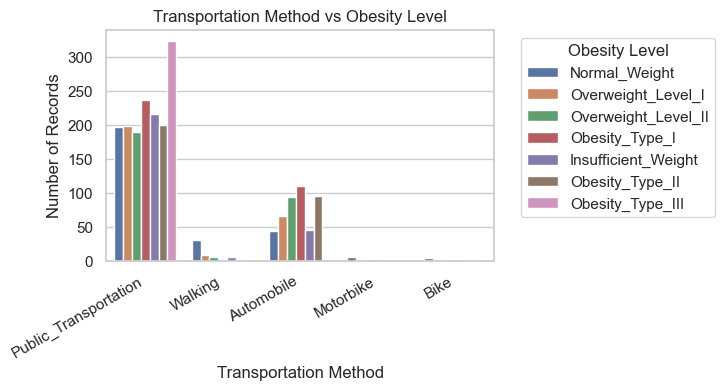

In [100]:
# Explore the relationship between family history and obesity level
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x="family_history_with_overweight", hue="NObeyesdad")
plt.title("Family History with Overweight vs Obesity Level")
plt.xlabel("Family History with Overweight")
plt.ylabel("Number of Records")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Explore the relationship between transportation and obesity level
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x="MTRANS", hue="NObeyesdad")
plt.title("Transportation Method vs Obesity Level")
plt.xlabel("Transportation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

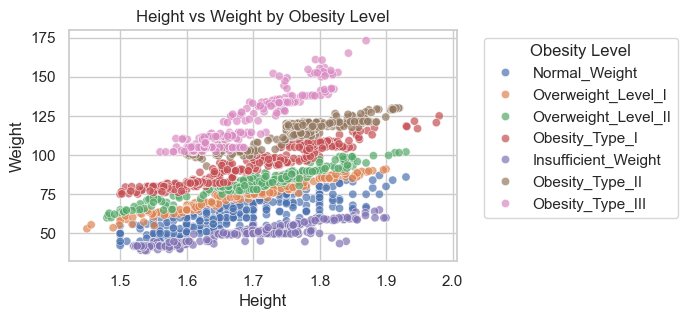

In [101]:
# Explore the relationship between height,weight and obesity level
plt.figure(figsize=(5, 3))
sns.scatterplot(data=data, x="Height", y="Weight", hue="NObeyesdad", alpha=0.7)
plt.title("Height vs Weight by Obesity Level")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.legend(title="Obesity Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

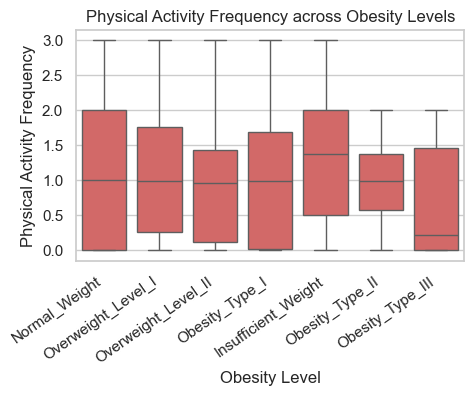

In [13]:
# Explore the relationship between physical activity and obesity level
plt.figure(figsize=(5, 3))
sns.boxplot(data=data, x="NObeyesdad", y="FAF",  color="#E45756")
plt.title("Physical Activity Frequency across Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Physical Activity Frequency")
plt.xticks(rotation=35, ha="right")
plt.show()

### Modelling

#### **Modelling Data Preparation**

* Encoding - change the categorical variable to numerical representation without changing the original meaning
* Feature Selection - to select tatget variable and predictor variable that is used for model development
* Target Variable: obesity level (NObeyesdad)
* Predictor Variable: all features except NObeyesdad, Height, Weight, BMI, Transportation
* The reason of removing transportation for obesity prediction is because firstly the majority of respondent bias to public transport, it is one of the reason why most of the individual with public transport having obesity 

In [102]:
excluded_columns = {TARGET_CLASS, "Height", "Weight", "BMI", "Obesity_Risk", "At_Risk","MTRANS"}
feature_columns = [column for column in data.columns if column not in excluded_columns]

X = data[feature_columns].copy()
y_labels = data[TARGET_CLASS].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
classes = label_encoder.classes_.tolist()

print("Features used:", feature_columns)
print("Target classes:", classes)
print("Feature matrix shape:", X.shape)

Features used: ['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC']
Target classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Feature matrix shape: (2087, 13)


In [103]:
def build_preprocessor(frame: pd.DataFrame) -> ColumnTransformer:
    numeric_features = [column for column in frame.columns if is_numeric_dtype(frame[column])]
    categorical_features = [column for column in frame.columns if column not in numeric_features]

    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]),
                categorical_features,
            ),
        ]
    )

#### **Data Splitting**

Split the dataset into training dataset and testing dataset (80% training, 20% testing)

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [105]:
# Display the data size for training and testing
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1669, 13)
(418, 13)
(1669,)
(418,)


#### **Model Training, Validation and Evaluation**

* The performance of each machine learning model is evaluated in terms of accuracy, F1 score, and AUC.
* Based on the results, Random Forest is the best performance model with the highest accuracy rate of 84.69%. HistGradientBoosting has a strong baseline and performs very closely, while LightGBM and XGBoost also produce competitive results.
* Logistic Regression and Gaussian Naive Bayes perform worse because the relationship between lifestyle variables and obesity level is likely non-linear.

In [106]:
y_test_labels = pd.Series(label_encoder.inverse_transform(y_test))

classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=500, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=400, random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=400, random_state=RANDOM_STATE, num_leaves=31, n_jobs=-1, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Gaussian NB": GaussianNB(),
}

trained_models = {}
comparison_rows = []

for model_name, classifier in classifiers.items():
    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X)),
        ("classifier", classifier),
    ])
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)

    obesity_idx = [classes.index(label) for label in classes if label in RISK_CLASSES]
    at_risk_idx = [classes.index(label) for label in classes if label in AT_RISK_CLASSES]
    obesity_target = y_test_labels.isin(RISK_CLASSES).astype(int)
    at_risk_target = y_test_labels.isin(AT_RISK_CLASSES).astype(int)

    metrics = {
        "accuracy": round(float(accuracy_score(y_test, predictions)), 4),
        "weighted_f1": round(float(f1_score(y_test, predictions, average="weighted")), 4),
        "obesity_auc": round(float(roc_auc_score(obesity_target, probabilities[:, obesity_idx].sum(axis=1))), 4),
        "overweight_or_obesity_auc": round(float(roc_auc_score(at_risk_target, probabilities[:, at_risk_idx].sum(axis=1))), 4),
        "classification_report": classification_report(
            y_test,
            predictions,
            target_names=classes,
            output_dict=True,
            zero_division=0,
        ),
    }

    trained_models[model_name] = {
        "pipeline": pipeline,
        "metrics": metrics,
    }
    comparison_rows.append({
        "Model": model_name,
        "Accuracy": metrics["accuracy"],
        "Weighted F1": metrics["weighted_f1"],
        "Obesity AUC": metrics["obesity_auc"],
        "Overweight/Obesity AUC": metrics["overweight_or_obesity_auc"],
    })

comparison_table = pd.DataFrame(comparison_rows).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(comparison_table)

,Model,Accuracy,Weighted F1,Obesity AUC,Overweight/Obesity AUC
0,HistGradientBoosting,0.8469,0.8471,0.9818,0.9713
1,LightGBM,0.8397,0.8400,0.9806,0.9688
2,Random Forest,0.8325,0.8317,0.9809,0.9682
3,XGBoost,0.8206,0.8196,0.9785,0.9674
4,Extra Trees,0.8158,0.8131,0.9772,0.9581
5,Logistic Regression,0.6148,0.5855,0.8848,0.9226
6,Gaussian NB,0.5239,0.4828,0.7936,0.8318


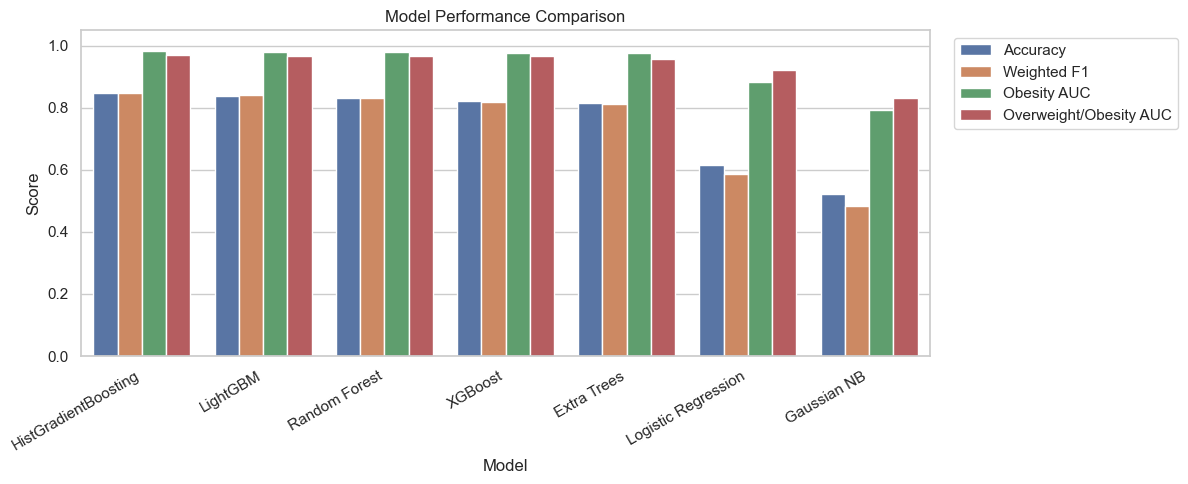

In [107]:
plt.figure(figsize=(12, 5))
comparison_plot = comparison_table.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Weighted F1", "Obesity AUC", "Overweight/Obesity AUC"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=comparison_plot, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [108]:
best_model_name = comparison_table.iloc[0]["Model"]
best_metrics = trained_models[best_model_name]["metrics"]

print("Best model:", best_model_name)
print("Accuracy:", best_metrics["accuracy"])
print("Weighted F1:", best_metrics["weighted_f1"])
print("Obesity AUC:", best_metrics["obesity_auc"])
print("Overweight/Obesity AUC:", best_metrics["overweight_or_obesity_auc"])

best_report = pd.DataFrame(best_metrics["classification_report"]).T
display(best_report)

Best model: HistGradientBoosting
Accuracy: 0.8469
Weighted F1: 0.8471
Obesity AUC: 0.9818
Overweight/Obesity AUC: 0.9713


,precision,recall,f1-score,support
Insufficient_Weight,0.827586,0.905660,0.864865,53.00000
Normal_Weight,0.656250,0.736842,0.694215,57.00000
Obesity_Type_I,0.847222,0.871429,0.859155,70.00000
Obesity_Type_II,0.918033,0.933333,0.925620,60.00000
Obesity_Type_III,1.000000,0.984615,0.992248,65.00000
Overweight_Level_I,0.816327,0.727273,0.769231,55.00000
Overweight_Level_II,0.860000,0.741379,0.796296,58.00000
accuracy,0.846890,0.846890,0.846890,0.84689
macro avg,0.846488,0.842933,0.843090,418.00000
weighted avg,0.850320,0.846890,0.847070,418.00000


### Model Deployment

The selected model and all comparison models are saved into a single joblib bundle. This allows the web app to display several model options while using the best model as the default choice.

In [109]:
FIELD_LABELS = {
    "Gender": "Gender",
    "Age": "Age",
    "family_history_with_overweight": "Family history with overweight",
    "FAVC": "Frequent high-calorie food",
    "FCVC": "Vegetable consumption frequency",
    "NCP": "Main meals per day",
    "CAEC": "Food between meals",
    "SMOKE": "Smoking",
    "CH2O": "Daily water intake",
    "SCC": "Calories monitoring",
    "FAF": "Physical activity frequency",
    "TUE": "Technology usage time",
    "CALC": "Alcohol consumption",
}

FEATURE_DESCRIPTIONS = {
    "Age": {"type": "number", "min": 14.0, "max": 61.0, "step": 1.0, "default": 23.0, "hint": "Age in years"},
    "FCVC": {"type": "number", "min": 1.0, "max": 3.0, "step": 0.1, "default": 2.4, "hint": "1 = low vegetables, 3 = high vegetables"},
    "NCP": {"type": "number", "min": 1.0, "max": 4.0, "step": 1.0, "default": 3.0, "hint": "Number of main meals per day"},
    "CH2O": {"type": "number", "min": 1.0, "max": 3.0, "step": 0.1, "default": 2.0, "hint": "1 = low water intake, 3 = high water intake"},
    "FAF": {"type": "number", "min": 0.0, "max": 3.0, "step": 0.1, "default": 1.0, "hint": "0 = none, 3 = very frequent activity"},
    "TUE": {"type": "number", "min": 0.0, "max": 2.0, "step": 0.1, "default": 0.6, "hint": "Technology use score from the dataset"},
}

categorical_options = {
    column: sorted(X[column].dropna().unique().tolist())
    for column in X.columns
    if not is_numeric_dtype(X[column])
}

feature_schema = {}
for column in feature_columns:
    if column in categorical_options:
        feature_schema[column] = {
            "type": "select",
            "label": FIELD_LABELS[column],
            "options": categorical_options[column],
        }
    else:
        spec = FEATURE_DESCRIPTIONS[column]
        feature_schema[column] = {
            "type": spec["type"],
            "label": FIELD_LABELS[column],
            "min": spec["min"],
            "max": spec["max"],
            "step": spec["step"],
            "default": spec["default"],
            "hint": spec["hint"],
        }

report = {
    "dataset_path": str(DATA_PATH.resolve()),
    "rows": int(len(data)),
    "features_used": feature_columns,
    "best_model": best_model_name,
    "model_metrics": {
        name: model_data["metrics"]
        for name, model_data in trained_models.items()
    },
    "notes": [
        "Inputs intentionally exclude height, weight, and BMI to avoid direct anthropometric leakage.",
        "Obesity probability is the summed probability of Obesity_Type_I, II, and III.",
        "The model is designed for lifestyle-based risk screening rather than BMI reconstruction.",
        f"Best performing model: {best_model_name}",
    ],
}

bundle = {
    "models": {
        name: {
            "pipeline": model_data["pipeline"],
            "metrics": {
                "accuracy": model_data["metrics"]["accuracy"],
                "weighted_f1": model_data["metrics"]["weighted_f1"],
                "obesity_auc": model_data["metrics"]["obesity_auc"],
                "overweight_or_obesity_auc": model_data["metrics"]["overweight_or_obesity_auc"],
            },
        }
        for name, model_data in trained_models.items()
    },
    "best_model": best_model_name,
    "feature_columns": feature_columns,
    "classes": classes,
    "risk_classes": sorted(RISK_CLASSES),
    "at_risk_classes": sorted(AT_RISK_CLASSES),
    "feature_schema": feature_schema,
    "notes": report["notes"],
}

joblib.dump(bundle, MODEL_PATH)
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("Saved model bundle to:", MODEL_PATH.resolve())
print("Saved model report to:", REPORT_PATH.resolve())

Saved model bundle to: C:\Users\cheny\Downloads\project\personal_obesity_bundle.joblib
Saved model report to: C:\Users\cheny\Downloads\project\personal_model_report.json


In [110]:
# Example single-person prediction using the saved bundle
bundle = joblib.load(MODEL_PATH)
example_payload = {
    "Gender": "Female",
    "Age": 23,
    "family_history_with_overweight": "yes",
    "FAVC": "no",
    "FCVC": 2.4,
    "NCP": 3.0,
    "CAEC": "Sometimes",
    "SMOKE": "no",
    "CH2O": 2.0,
    "SCC": "no",
    "FAF": 1.0,
    "TUE": 0.6,
    "CALC": "Sometimes",
}

sample = pd.DataFrame([example_payload], columns=bundle["feature_columns"])
pipeline = bundle["models"][bundle["best_model"]]["pipeline"]
probabilities = pipeline.predict_proba(sample)[0]

prediction_rows = pd.DataFrame({
    "class": bundle["classes"],
    "probability_percent": (probabilities * 100).round(2),
}).sort_values(by="probability_percent", ascending=False)

obesity_probability = prediction_rows.loc[prediction_rows["class"].isin(bundle["risk_classes"]), "probability_percent"].sum()
at_risk_probability = prediction_rows.loc[prediction_rows["class"].isin(bundle["at_risk_classes"]), "probability_percent"].sum()

print("Best model:", bundle["best_model"])
print("Obesity probability (%):", round(float(obesity_probability), 2))
print("Overweight or obesity probability (%):", round(float(at_risk_probability), 2))
display(prediction_rows)

Best model: HistGradientBoosting
Obesity probability (%): 0.32
Overweight or obesity probability (%): 77.12


,class,probability_percent
6,Overweight_Level_II,68.92
1,Normal_Weight,22.26
5,Overweight_Level_I,7.88
0,Insufficient_Weight,0.62
2,Obesity_Type_I,0.27
3,Obesity_Type_II,0.05
4,Obesity_Type_III,0.00


#### Run the web app locally

In [ ]:
%run web_app.py

Web app running at http://127.0.0.1:8000
